# 03 — Porównanie modeli

## Cel

W tym notebooku porównuję wszystkie wymagane rodziny modeli na tym samym zbiorze treningowym.

Każdy model dostaje:

- 5-fold cross-validation,
- taki sam podział danych,
- imputację medianą w `Pipeline`,
- skalowanie tylko tam, gdzie jest potrzebne,
- niewielkie strojenie jednego ważnego parametru.

Na końcu zapisuję jedną tabelę `wyniki_modeli.csv`. Trzy najlepsze modele przejdą do ostatniego notebooka.

## 1. Importy i dane

In [1]:
from pathlib import Path
from time import perf_counter
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

DATA_PATH = Path("dane/5year_cleaned.csv")

df = pd.read_csv(DATA_PATH)
feature_cols = [col for col in df.columns if col != "class"]

# Odtwarzam ten sam podział 64/16/20.
development, test = train_test_split(
    df,
    test_size=0.20,
    stratify=df["class"],
    random_state=42
)

train, validation = train_test_split(
    development,
    test_size=0.20,
    stratify=development["class"],
    random_state=42
)

X_train = train[feature_cols].copy()
y_train = train["class"].copy()

# Dwie nowe cechy wynikają bezpośrednio z obserwacji z EDA.
X_train["missing_count"] = X_train[feature_cols].isna().sum(axis=1)
X_train["has_missing"] = (X_train["missing_count"] > 0).astype(int)

print("Trening:", X_train.shape)
print("Udział klasy 1:", round(y_train.mean(), 4))

Trening: (3744, 66)
Udział klasy 1: 0.0697


## 2. Pipeline

In [2]:
def make_pipeline(model, scale=False):
    # Imputer uczy mediany wyłącznie na aktualnej części treningowej danego foldu.
    steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True))
    ]

    # Regresja logistyczna, kNN, SVM i MLP są wrażliwe na różne skale cech.
    if scale:
        steps.append(("scaler", StandardScaler()))

    # Ostatnim krokiem Pipeline jest właściwy klasyfikator.
    steps.append(("model", model))
    return Pipeline(steps)

## 3. Modele i małe zakresy strojenia

Nie robię dużych siatek dla wszystkich algorytmów. Dla każdego sprawdzam trzy wartości jednego ważnego parametru.

To wystarcza do pierwszego porównania i nie powoduje bardzo długiego czasu obliczeń.

Dla MLP porównuję trzy małe architektury. Dla każdej sprawdzam trzy wartości `alpha`.

In [3]:
# Dla każdej rodziny podaję model, informację o skalowaniu i małą siatkę parametrów.
configs = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1500, random_state=42),
        "scale": True,
        "grid": {"model__C": [0.1, 1.0, 10.0]},
    },
    "kNN": {
        "model": KNeighborsClassifier(),
        "scale": True,
        "grid": {"model__n_neighbors": [3, 5, 11]},
    },
    "SVM": {
        "model": SVC(kernel="rbf"),
        "scale": True,
        "grid": {"model__C": [0.5, 1.0, 2.0]},
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "scale": False,
        "grid": {"model__max_depth": [3, 6, None]},
    },
    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=150,
            random_state=42,
            n_jobs=1
        ),
        "scale": False,
        "grid": {"model__max_depth": [5, 10, None]},
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(
            n_estimators=120,
            random_state=42
        ),
        "scale": False,
        "grid": {"model__learning_rate": [0.03, 0.05, 0.10]},
    },
    "XGBoost": {
        "model": XGBClassifier(
            n_estimators=150,
            learning_rate=0.05,
            eval_metric="logloss",
            random_state=42,
            n_jobs=1
        ),
        "scale": False,
        "grid": {"model__max_depth": [2, 3, 5]},
    },
    "LightGBM": {
        "model": LGBMClassifier(
            n_estimators=150,
            learning_rate=0.05,
            random_state=42,
            n_jobs=1,
            verbosity=-1
        ),
        "scale": False,
        "grid": {"model__num_leaves": [15, 31, 63]},
    },
}

mlp_architectures = {
    "MLP (32)": (32,),
    "MLP (64, 32)": (64, 32),
    "MLP (64, 32, 16)": (64, 32, 16),
}

# MLP sprawdzam w trzech małych architekturach; dla każdej stroję alpha.
for name, layers in mlp_architectures.items():
    configs[name] = {
        "model": MLPClassifier(
            hidden_layer_sizes=layers,
            max_iter=250,
            early_stopping=True,
            random_state=42
        ),
        "scale": True,
        "grid": {"model__alpha": [0.0001, 0.001, 0.01]},
    }

print("Liczba konfiguracji:", len(configs))

Liczba konfiguracji: 11


## 4. Metryki i 5-fold cross-validation

In [4]:
# StratifiedKFold zachowuje zbliżony udział klasy 1 w każdym foldzie.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Liczę kilka metryk jednocześnie.
# AP jest główną metryką porównania, ale nie ignoruję recall i F1.
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "ap": "average_precision",
}

## 5. Porównanie modeli

Główną metryką do ustawienia kolejności jest **Average Precision (AP)**.

Przy rzadkiej klasie `1` jest bardziej informacyjna niż sama `accuracy`.

In [5]:
results = []

for name, config in configs.items():
    print("Model:", name, flush=True)

    # clone() daje świeżą kopię modelu dla kolejnego wyszukiwania.
    pipeline = make_pipeline(
        clone(config["model"]),
        scale=config["scale"]
    )

    # GridSearchCV sprawdza 3 ustawienia danego modelu.
    # refit="ap" oznacza, że najlepsze ustawienie wybieram według Average Precision.
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["grid"],
        scoring=scoring,
        refit="ap",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    # Mierzę cały czas wyszukiwania oraz średni czas pojedynczego fitu.
    start = perf_counter()
    search.fit(X_train, y_train)
    search_time = perf_counter() - start

    idx = search.best_index_

    # Zapisuję tylko wynik najlepszego ustawienia z danej rodziny.
    results.append({
        "model": name,
        "accuracy_mean": search.cv_results_["mean_test_accuracy"][idx],
        "accuracy_std": search.cv_results_["std_test_accuracy"][idx],
        "precision_mean": search.cv_results_["mean_test_precision"][idx],
        "recall_mean": search.cv_results_["mean_test_recall"][idx],
        "f1_mean": search.cv_results_["mean_test_f1"][idx],
        "roc_auc_mean": search.cv_results_["mean_test_roc_auc"][idx],
        "ap_mean": search.cv_results_["mean_test_ap"][idx],
        "ap_std": search.cv_results_["std_test_ap"][idx],
        "fit_time_mean": search.cv_results_["mean_fit_time"][idx],
        "search_time_s": search_time,
        "best_params": json.dumps(search.best_params_, ensure_ascii=False),
    })

# Najpierw pokazuję modele o najwyższym AP.
results_df = (
    pd.DataFrame(results)
    .sort_values(["ap_mean", "fit_time_mean"], ascending=[False, True])
    .reset_index(drop=True)
)

display(results_df.round(4))

Model: Logistic Regression
Model: kNN
Model: SVM
Model: Decision Tree
Model: Random Forest
Model: Gradient Boosting
Model: XGBoost
Model: LightGBM
Model: MLP (32)
Model: MLP (64, 32)
Model: MLP (64, 32, 16)


,model,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,ap_mean,ap_std,fit_time_mean,search_time_s,best_params
0,LightGBM,0.9661,0.0041,0.9139,0.5673,0.6982,0.9567,0.7909,0.0381,1.1907,11.6950,"{""model__num_leaves"": 15}"
1,XGBoost,0.9623,0.0030,0.8889,0.5287,0.6607,0.9492,0.7725,0.0397,1.5144,5.7669,"{""model__max_depth"": 5}"
2,Gradient Boosting,0.9605,0.0067,0.8764,0.5021,0.6364,0.9307,0.7224,0.0523,9.5211,43.9202,"{""model__learning_rate"": 0.05}"
3,Random Forest,0.9503,0.0052,0.8233,0.3720,0.5085,0.9191,0.6441,0.0646,2.3260,11.4048,"{""model__max_depth"": null}"
4,SVM,0.9490,0.0028,0.9390,0.2874,0.4397,0.8525,0.5875,0.0197,0.2426,3.4207,"{""model__C"": 2.0}"
5,"MLP (64, 32)",0.9509,0.0047,0.8596,0.3607,0.4991,0.8633,0.5675,0.0561,0.8532,6.6517,"{""model__alpha"": 0.001}"
6,Logistic Regression,0.9501,0.0038,0.7619,0.4178,0.5385,0.8758,0.5598,0.0423,0.2009,3.9666,"{""model__C"": 10.0}"
7,"MLP (64, 32, 16)",0.9487,0.0046,0.7866,0.3640,0.4907,0.8651,0.5566,0.0650,1.0169,8.3003,"{""model__alpha"": 0.01}"
8,kNN,0.9522,0.0027,0.8593,0.3794,0.5241,0.8375,0.5370,0.0295,0.0497,2.0561,"{""model__n_neighbors"": 11}"
9,MLP (32),0.9479,0.0061,0.7709,0.3718,0.4989,0.8514,0.5192,0.0533,0.5810,4.0544,"{""model__alpha"": 0.01}"


### Wnioski z porównania

Najlepsze trzy wyniki uzyskały modele boostingowe:

- **LightGBM** — AP `0,7909 ± 0,0381`, F1 `0,698`, recall `0,567`,
- **XGBoost** — AP `0,7725 ± 0,0397`, F1 `0,661`, recall `0,529`,
- **Gradient Boosting** — AP `0,7224 ± 0,0523`, F1 `0,636`, recall `0,502`.

LightGBM ma nie tylko najwyższe AP, ale też mały rozrzut między foldami i krótki średni czas uczenia około **1,2 s na fold**.

Gradient Boosting jest wyraźnie wolniejszy — około **9,5 s na fold** — a jednocześnie ma niższe AP. To będzie ważne przy końcowym porównaniu jakości i kosztu.

Widać też, dlaczego nie warto patrzeć na jedną metrykę. SVM ma bardzo wysokie precision, ale recall jest niski, więc wykrywa tylko część rzeczywistych bankructw.

## 6. Proste porównanie jakości i czasu

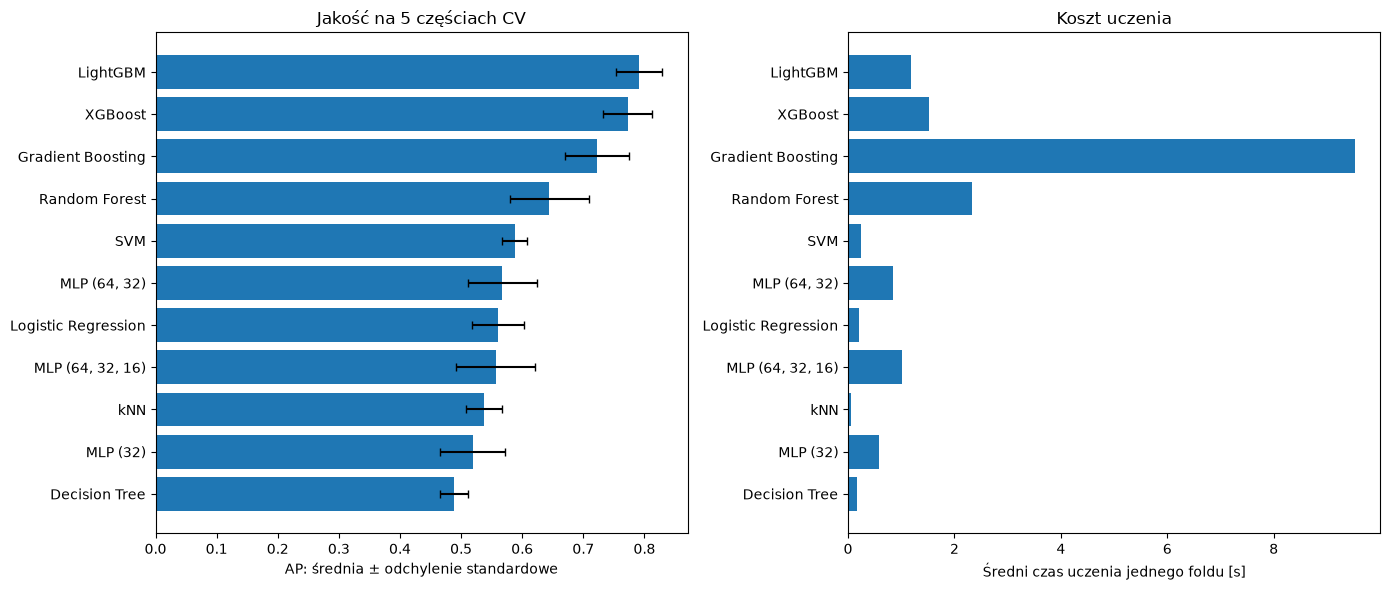

In [6]:
# Ten sam porządek modeli wykorzystuję na obu wykresach.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
positions = np.arange(len(results_df))

# Lewy wykres: jakość i jej zmienność między foldami.
axes[0].barh(
    positions,
    results_df["ap_mean"],
    xerr=results_df["ap_std"],
    capsize=3
)
axes[0].set_yticks(positions, results_df["model"])
axes[0].invert_yaxis()
axes[0].set_xlabel("AP: średnia ± odchylenie standardowe")
axes[0].set_title("Jakość na 5 częściach CV")

# Prawy wykres: średni koszt pojedynczego uczenia.
axes[1].barh(
    positions,
    results_df["fit_time_mean"]
)
axes[1].set_yticks(positions, results_df["model"])
axes[1].invert_yaxis()
axes[1].set_xlabel("Średni czas uczenia jednego foldu [s]")
axes[1].set_title("Koszt uczenia")

plt.tight_layout()
plt.show()

## 7. Trzy najlepsze modele

In [7]:
# Do kolejnego etapu przechodzą tylko trzy najlepsze modele według AP.
top3 = results_df.head(3).copy()

display(
    top3[
        ["model", "ap_mean", "ap_std", "f1_mean", "recall_mean", "fit_time_mean"]
    ].round(4)
)

print("Do dalszego etapu przechodzą:")
for name in top3["model"]:
    print("-", name)

# Ten mały plik przekazuje wyniki notebooka 03 do notebooka 04.
# Nie zapisuję osobno modeli ani dziesiątek tabel pomocniczych.
results_df.to_csv("wyniki_modeli.csv", index=False)
print("\nZapisano: wyniki_modeli.csv")

,model,ap_mean,ap_std,f1_mean,recall_mean,fit_time_mean
0,LightGBM,0.7909,0.0381,0.6982,0.5673,1.1907
1,XGBoost,0.7725,0.0397,0.6607,0.5287,1.5144
2,Gradient Boosting,0.7224,0.0523,0.6364,0.5021,9.5211


Do dalszego etapu przechodzą:
- LightGBM
- XGBoost
- Gradient Boosting

Zapisano: wyniki_modeli.csv


## Podsumowanie

Wszystkie 11 konfiguracji zostało porównanych na tych samych pięciu foldach.

Do dokładniejszego strojenia przechodzą:

1. **LightGBM**,
2. **XGBoost**,
3. **Gradient Boosting**.

Nie ma potrzeby wykonywać ciężkiego tuningu wszystkich modeli. W notebooku 03 każdy dostał małe, uczciwe strojenie, a większy budżet obliczeniowy przeznaczam tylko na trzy najlepsze wyniki.

`wyniki_modeli.csv` jest jedynym dodatkowym plikiem tworzonym na tym etapie i będzie używany w notebooku 04.